# Stage 02 - Baseline CPU Solver for ADAN-86 Pressure Propagation v1

This notebook builds the first stable CPU-based 1D pulse-wave solver for the parsed ADAN-86 arterial network.

The input is the parsed network file produced by Stage 01:

```python
adan_parsed.pkl

## Load parsed ADAN network

This notebook starts from the parsed ADAN-86 network created in Stage 01.

The pickle file contains:

- vessel names and traversal order
- topology tables
- root vessel index
- terminal vessel indices
- vessel geometry
- wall stiffness parameters
- numerical grid sizes
- wave speeds
- characteristic impedances

These arrays allow the solver to operate directly on NumPy arrays instead of repeatedly using DataFrames.

In [1]:
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import trapezoid

# Load parsed ADAN data


with open("adan_parsed.pkl", "rb") as f:
    adan = pickle.load(f)

globals().update(adan)

print("Loaded ADAN parsed data")
print("Vessels:", len(order))
print("Topology rows:", len(topology_df))
print("Terminals:", len(terminal_idx))
print("dt_global:", dt_global)
print("max Nv:", np.max(Nv))

Loaded ADAN parsed data
Vessels: 103
Topology rows: 102
Terminals: 43
dt_global: 0.00012883511995154115
max Nv: 79


## Solver time step and CFL safety factor

The parser provides an estimated global time step, but for the first stable baseline solver  use a more conservative CFL value.

The CFL condition controls how far information can travel during one numerical time step.

For this baseline run CFL_SOLVER was used:

```python
CFL_SOLVER = 0.10

In [2]:
# SOLVER TIME STEP OVERRIDE
# Parser dt_global is only a suggestion.
# For the baseline solver we use a safer CFL.

CFL_SOLVER = 0.10

dt_global = CFL_SOLVER * np.min(dxv / c0v)

print("CFL_SOLVER:", CFL_SOLVER)
print("dt_global:", dt_global)
print("n_steps for 2s:", int(2.0 / dt_global))

cfl_actual = c0v * dt_global / dxv
print("max CFL actual:", cfl_actual.max())
print("min CFL actual:", cfl_actual.min())

CFL_SOLVER: 0.1
dt_global: 3.220877998788529e-05
n_steps for 2s: 62094
max CFL actual: 0.1
min CFL actual: 0.02037980844142134


## Pressure-area wall law

Each artery is treated as a compliant 1D tube.

The solver needs a relationship between cross-sectional area and pressure.  
Here we use a simple elastic wall law:

```text
P = beta · (sqrt(A) - sqrt(A0))

In [ ]:
def area_to_pressure(A, A0, beta):
    """
    Convert vessel area to pressure using the wall law.

    Args:
        A: Current vessel area.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.

    Returns:
        Pressure relative to external pressure in Pa.
    """
    A_safe = np.maximum(A, 1e-14)
    return beta * (np.sqrt(A_safe) - np.sqrt(A0))


def area_to_pressure(A, A0, beta):
    """
    Convert vessel area to pressure using the wall law.

    Args:
        A: Current vessel area.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.

    Returns:
        Pressure relative to external pressure in Pa.
    """
    sqrt_A = P / beta + np.sqrt(A0)
    sqrt_A = np.maximum(sqrt_A, 1e-14)
    return sqrt_A**2

## Synthetic cardiac inflow waveform

The heart is represented as a prescribed inflow waveform at the root vessel.

Cardiac chambers or valves are not modeled in this notebook.  
Instead, the aortic root receives a synthetic flow pulse with:

- one cardiac cycle per second
- systolic ejection phase
- broad systolic peak
- small negative recoil after systole
- calibrated stroke volume

The waveform is scaled so that the integral over one cardiac cycle equals the target stroke volume.

This gives the arterial network a realistic driving signal while keeping the model simple.

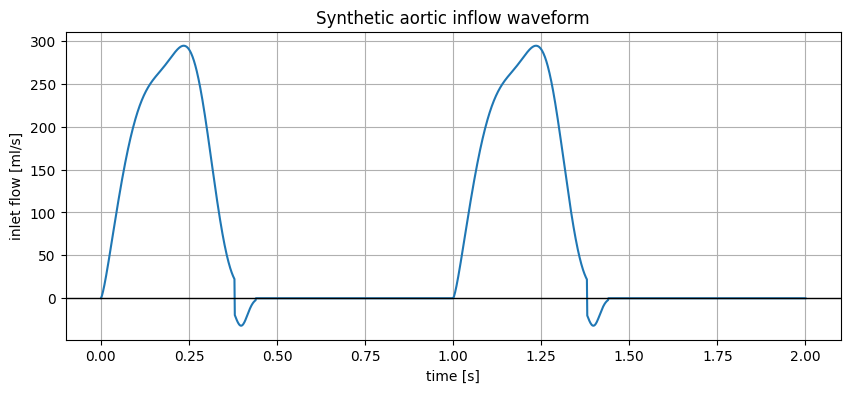

Q peak [ml/s]: 294.398723353155
Q min [ml/s]: -32.0334664240778
Stroke volume first cycle [ml]: 69.98942574610462


In [ ]:
T_CARDIAC = 1.0 # [s], 60 bpm
T_SYS = 0.38 # [s], systolic ejection duration

STROKE_VOLUME_ML = 70.0
STROKE_VOLUME = STROKE_VOLUME_ML * 1e-6  # [m^3]


def inlet_shape_raw(tau):
    """
    Compute the raw dimensionless aortic inflow shape.

    Creates a broad systolic forward-flow pulse with a small
    negative recoil component after systole.

    Args:
        tau: Time within one cardiac cycle.

    Returns:
        Dimensionless inlet flow value.
    """

    if tau < 0.0:
        return 0.0

    if tau < T_SYS:
        x = tau / T_SYS

        a = 1.4
        b = 2.2

        main = (x ** a) * ((1.0 - x) ** b)

        shoulder = 0.06 * np.exp(
            -0.5 * ((tau - 0.27) / 0.055) ** 2
        )

        return main + shoulder

    elif tau < T_SYS + 0.06:
        return -0.012 * np.exp(
            -0.5 * ((tau - (T_SYS + 0.018)) / 0.018) ** 2
        )

    else:
        return 0.0


# Calibrate to stroke volume
ts_cal = np.linspace(0, T_CARDIAC, 3000)
shape = np.array([inlet_shape_raw(t) for t in ts_cal])
area_shape = trapezoid(shape, ts_cal)

Q_SCALE = STROKE_VOLUME / area_shape


def inlet_flow(t):
    """
    Compute scaled periodic inlet flow at simulation time t.

    Converts time to cardiac-cycle phase and scales the raw waveform
    to match the target stroke volume.

    Args:
        t: Simulation time.

    Returns:
        Inlet flow value.
    """
    tau = t % T_CARDIAC
    return Q_SCALE * inlet_shape_raw(tau)


# Diagnostic plot
ts = np.linspace(0, 2.0, 2000)
qs = np.array([inlet_flow(t) for t in ts])

plt.figure(figsize=(10, 4))
plt.plot(ts, qs * 1e6)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("time [s]")
plt.ylabel("inlet flow [ml/s]")
plt.title("Synthetic aortic inflow waveform")
plt.grid(True)
plt.show()

print("Q peak [ml/s]:", qs.max() * 1e6)
print("Q min [ml/s]:", qs.min() * 1e6)
print("Stroke volume first cycle [ml]:", trapezoid(qs[ts < 1.0], ts[ts < 1.0]) * 1e6)

## Initial pressure state

The simulation starts from a uniform reference pressure:

```python
P_REF = 90 mmHg

In [ ]:
P_REF = 90.0 * MMHG
P_VENOUS = 5.0 * MMHG


def initialize_state(A0v, betav, Nv, P_init):
    """
    Initialize vessel area and flow arrays.

    Sets each vessel to uniform initial pressure and zero flow.

    Args:
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Nv: Number of grid points per vessel.
        P_init: Initial pressure.

    Returns:
        (A, Q) initialized vessel area and flow lists.
    """

    A = []
    Q = []

    for i in range(len(A0v)):
        A_init = pressure_to_area(P_init, A0v[i], betav[i])

        A.append(np.full(Nv[i], A_init, dtype=float))
        Q.append(np.zeros(Nv[i], dtype=float))

    return A, Q


A_ref_v = np.array([
    pressure_to_area(P_REF, A0v[i], betav[i])
    for i in range(len(A0v))
])

print("P_REF mmHg:", P_REF / MMHG)
print("A_ref/A0 range:", np.min(A_ref_v / A0v), np.max(A_ref_v / A0v))

P_REF mmHg: 90.0
A_ref/A0 range: 1.1156539621322352 2.1164960254420455


## MacCormack solver step

The interior points of each vessel are updated using a MacCormack predictor-corrector scheme.

The solved variables are:

```text
A = cross-sectional area
Q = volumetric flow

In [ ]:
def compute_flux(A, Q, A0, beta, rho=RHO):
    """
    Compute conservative fluxes for one vessel.

    Args:
        A: Vessel area array.
        Q: Flow array.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.
        rho: Blood density.

    Returns:
        (F1, F2) flux arrays.
    """

    A_safe = np.maximum(A, 1e-12)

    P = area_to_pressure(A_safe, A0, beta)

    F1 = Q
    F2 = Q**2 / A_safe + P * A_safe / rho

    return F1, F2


def maccormack_step(A, Q, A0, beta, dx, dt):
    """
    Run one MacCormack predictor-corrector step for one vessel.

    Updates vessel values using flux differences. Boundary points
    are expected to be handled outside this function.

    Args:
        A: Vessel area array.
        Q: Flow array.
        A0: Reference vessel area.
        beta: Vessel stiffness parameter.
        dx: Spatial step size.
        dt: Time step.

    Returns:
        Updated (A_new, Q_new) arrays.
    """

    N = len(A)

    if N < 3:
        return A, Q

    A_new = A.copy()
    Q_new = Q.copy()

    # Predictor
    F1, F2 = compute_flux(A, Q, A0, beta)

    A_pred = A.copy()
    Q_pred = Q.copy()

    A_pred[:-1] = A[:-1] - dt / dx * (F1[1:] - F1[:-1])
    Q_pred[:-1] = Q[:-1] - dt / dx * (F2[1:] - F2[:-1])

    A_pred = np.maximum(A_pred, 1e-12)

    # Corrector
    F1p, F2p = compute_flux(A_pred, Q_pred, A0, beta)

    A_new[1:] = 0.5 * (
        A[1:] + A_pred[1:] - dt / dx * (F1p[1:] - F1p[:-1])
    )

    Q_new[1:] = 0.5 * (
        Q[1:] + Q_pred[1:] - dt / dx * (F2p[1:] - F2p[:-1])
    )

    A_new = np.maximum(A_new, 1e-12)

    return A_new, Q_new


def step_all_vessels_uncoupled(A, Q, A0v, betav, dxv, dt):
    """
    Apply one MacCormack step independently to all vessels.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        dxv: Spatial step size per vessel.
        dt: Time step.

    Returns:
        Updated (A_new, Q_new) vessel lists.
    """

    A_new = []
    Q_new = []

    for i in range(len(A)):
        Ai, Qi = maccormack_step(
            A[i],
            Q[i],
            A0v[i],
            betav[i],
            dxv[i],
            dt
        )

        A_new.append(Ai)
        Q_new.append(Qi)

    return A_new, Q_new

## Baseline vessel connection coupling

After each vessel interior is updated, connected vessels must exchange pressure and flow information.

This baseline solver uses a simplified wave-aware coupling method.

It is not a full nonlinear Riemann solver at bifurcations.  
Instead, it estimates an interface pressure using characteristic impedance and then updates inlet/outlet flow using a linear wave relation:

```text
dQ = dP / Z0

In [ ]:
def apply_connections_simple(A, Q, children_map_idx, A0v, betav, Z0v):
    """
    Apply simple wave-aware coupling between connected vessels.

    Computes a shared interface pressure at each linear connection
    or bifurcation, then updates boundary area and flow using a
    pressure-jump over impedance relation.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        children_map_idx: Mapping from parent vessel index to child indices.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.

    Returns:
        Updated (A, Q) vessel lists.
    """

    for parent, children in children_map_idx.items():

        Pp = area_to_pressure(
            A[parent][-1],
            A0v[parent],
            betav[parent]
        )

        Qp = Q[parent][-1]

        # Linear connection
        if len(children) == 1:

            child = children[0]

            Pc = area_to_pressure(
                A[child][0],
                A0v[child],
                betav[child]
            )

            Qc = Q[child][0]

            gp = 1.0 / Z0v[parent]
            gc = 1.0 / Z0v[child]

            # shared pressure at interface
            P_int = (gp * Pp + gc * Pc) / (gp + gc)

            # wave update:
            # child inlet flow changes according to pressure jump
            Q_child_new = Qc + (P_int - Pc) / Z0v[child]

            # parent outlet gets same flow for conservation at this simple interface
            Q_parent_new = Q_child_new

            A[parent][-1] = pressure_to_area(
                P_int,
                A0v[parent],
                betav[parent]
            )

            A[child][0] = pressure_to_area(
                P_int,
                A0v[child],
                betav[child]
            )

            Q[parent][-1] = Q_parent_new
            Q[child][0] = Q_child_new


        # Bifurcation
        elif len(children) == 2:

            c1, c2 = children

            P1 = area_to_pressure(
                A[c1][0],
                A0v[c1],
                betav[c1]
            )

            P2 = area_to_pressure(
                A[c2][0],
                A0v[c2],
                betav[c2]
            )

            Q1_old = Q[c1][0]
            Q2_old = Q[c2][0]

            gp = 1.0 / Z0v[parent]
            g1 = 1.0 / Z0v[c1]
            g2 = 1.0 / Z0v[c2]

            # shared junction pressure
            P_int = (gp * Pp + g1 * P1 + g2 * P2) / (gp + g1 + g2)

            # wave-consistent child inlet updates
            Q1 = Q1_old + (P_int - P1) / Z0v[c1]
            Q2 = Q2_old + (P_int - P2) / Z0v[c2]

            A[parent][-1] = pressure_to_area(
                P_int,
                A0v[parent],
                betav[parent]
            )

            A[c1][0] = pressure_to_area(
                P_int,
                A0v[c1],
                betav[c1]
            )

            A[c2][0] = pressure_to_area(
                P_int,
                A0v[c2],
                betav[c2]
            )

            # parent flow equals total outflow into children
            Q[parent][-1] = Q1 + Q2
            Q[c1][0] = Q1
            Q[c2][0] = Q2

    return A, Q

## 3-element Windkessel terminal setup

Terminal arteries are connected to simplified downstream vascular beds.

Each terminal vessel receives a 3-element Windkessel model:

```text
R1 — proximal resistance
C  — compliance
R2 — distal resistance

In [8]:
P_VENOUS = 5.0 * MMHG  # 5 mmHg

# Approx global peripheral resistance:
# pressure drop / cardiac output
# 70 ml/s = 4.2 L/min
TOTAL_R = (100.0 * MMHG - P_VENOUS) / (70e-6)

terminal_A0 = A0v[terminal_idx]
weights = terminal_A0 / terminal_A0.sum()

R_total_i = TOTAL_R / weights

wk_R1 = np.zeros(len(A0v))
wk_R2 = np.zeros(len(A0v))
wk_C = np.zeros(len(A0v))
wk_Pc = np.zeros(len(A0v))

terminal_pos = {
    int(idx): k
    for k, idx in enumerate(terminal_idx)
}

for i in terminal_idx:
    k = terminal_pos[int(i)]

    R_total = R_total_i[k]

    wk_R1[i] = 0.10 * R_total
    wk_R2[i] = 0.90 * R_total

    # crude compliance allocation
    wk_C[i] = 1.5e-9 * weights[k]

    wk_Pc[i] = P_REF

print("Terminals:", len(terminal_idx))
print("TOTAL_R:", TOTAL_R)
print("R1 range:", wk_R1[wk_R1 > 0].min(), wk_R1.max())
print("R2 range:", wk_R2[wk_R2 > 0].min(), wk_R2.max())
print("C range:", wk_C[wk_C > 0].min(), wk_C.max())

Terminals: 43
TOTAL_R: 180937000.00000003
R1 range: 293747734.9833211 7480205480.287597
R2 range: 2643729614.8498893 67321849322.58836
C range: 3.628316103283905e-12 9.239407412466019e-11


## Windkessel terminal boundary condition

At each terminal vessel, the solver applies a 3-element Windkessel boundary condition.

The terminal boundary condition does three things:

1. estimates outgoing wave information from the last interior point  
2. computes terminal outflow using characteristic impedance and proximal resistance  
3. updates the Windkessel capacitor pressure over time  

The capacitor pressure evolves according to:

```text
C · dPc/dt = Qout - (Pc - Pv) / R2

In [ ]:
def apply_windkessel_terminals(A, Q, terminal_idx, A0v, betav, Z0v,
                               wk_R1, wk_R2, wk_C, wk_Pc,
                               dt, P_venous=P_VENOUS):
    """
    Apply 3-element Windkessel boundary conditions at terminal vessels.

    Uses characteristic coupling from the last interior point to compute
    outlet flow, update capacitor pressure, and impose terminal pressure
    and flow.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        terminal_idx: Indices of terminal vessels.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.
        wk_R1: Proximal Windkessel resistance array.
        wk_R2: Distal Windkessel resistance array.
        wk_C: Windkessel compliance array.
        wk_Pc: Windkessel capacitor pressure array.
        dt: Time step.
        P_venous: Venous pressure.

    Returns:
        Updated (A, Q, wk_Pc).
    """

    for i in terminal_idx:

        P_inside = area_to_pressure(
            A[i][-2],
            A0v[i],
            betav[i]
        )

        Q_inside = Q[i][-2]
        Z = Z0v[i]

        W_plus = Q_inside + P_inside / Z

        Q_out = (Z * W_plus - wk_Pc[i]) / (Z + wk_R1[i])

        # Safety: allow some reverse flow, avoid numerical insanity
        Q_out = np.clip(Q_out, -5e-5, 5e-4)

        dPc_dt = (
            Q_out - (wk_Pc[i] - P_venous) / wk_R2[i]
        ) / wk_C[i]

        wk_Pc[i] += dt * dPc_dt

        wk_Pc[i] = np.clip(
            wk_Pc[i],
            P_venous,
            180.0 * MMHG
        )

        P_terminal = wk_Pc[i] + wk_R1[i] * Q_out

        P_terminal = np.clip(
            P_terminal,
            40.0 * MMHG,
            180.0 * MMHG
        )

        A[i][-1] = pressure_to_area(
            P_terminal,
            A0v[i],
            betav[i]
        )

        Q[i][-1] = Q_out

    return A, Q, wk_Pc

## Numerical stabilization

This baseline solver uses simple numerical limiters to prevent unstable or non-physical states.

The stabilizer limits:

- vessel area relative to the reference pressure area
- flow velocity `u = Q / A`

This is not a physiological model component.  
It is a numerical safety mechanism used to keep the first CPU baseline stable.

The final active stabilizer clips area to:

```text
0.85 · A_ref ≤ A ≤ 1.35 · A_ref

In [ ]:
def limit_flow_velocity(A, Q, vmax=2.0):
    """
    Limit flow velocity by clipping u = Q / A.

    Args:
        A: Vessel area array.
        Q: Flow array.
        vmax: Maximum allowed velocity magnitude.

    Returns:
        Flow array after velocity limiting.
    """
    A_safe = np.maximum(A, 1e-12)
    u = Q / A_safe
    u_limited = np.clip(u, -vmax, vmax)
    return u_limited * A_safe


def stabilize_all(A, Q, A_ref_v, vmax=2.0):
    """
    Stabilize vessel states by clamping area and velocity.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        A_ref_v: Reference area per vessel.
        vmax: Maximum allowed velocity magnitude.

    Returns:
        Stabilized (A, Q) vessel lists.
    """
    for i in range(len(A)):
        A[i] = np.clip(
            A[i],
            0.85 * A_ref_v[i],
            1.35 * A_ref_v[i]
        )

        Q[i] = limit_flow_velocity(
            A[i],
            Q[i],
            vmax=vmax
        )

    return A, Q

## Root inlet boundary condition

The aortic root receives the prescribed cardiac inflow waveform.

Instead of simply forcing both pressure and flow, this boundary condition prescribes inlet flow and estimates inlet pressure using a Riemann-like compatibility relation with the first interior point.

This is important because directly imposing both pressure and flow would over-constrain the hyperbolic 1D system.

The boundary condition therefore:

1. evaluates the target inflow `Q_in(t)`
2. reads pressure and flow from the first interior grid point
3. estimates inlet pressure using characteristic impedance
4. converts that pressure back into inlet area
5. sets the inlet flow to the prescribed waveform

This gives a more stable and physically consistent root boundary than simply assigning `Q[0] = Q_in`.

In [ ]:
def apply_root_inlet_riemann(A, Q, root_idx, t, A0v, betav, Z0v):
    """
    Apply a Riemann-like inlet boundary condition at the root vessel.

    Prescribes inlet flow and computes compatible inlet pressure
    and area from the first interior point.

    Args:
        A: List of vessel area arrays.
        Q: List of vessel flow arrays.
        root_idx: Index of the root vessel.
        t: Current simulation time.
        A0v: Reference area per vessel.
        betav: Stiffness parameter per vessel.
        Z0v: Characteristic impedance per vessel.

    Returns:
        Updated (A, Q) vessel lists.
    """

    Q_in = inlet_flow(t)

    A_inside = A[root_idx][1]
    Q_inside = Q[root_idx][1]

    P_inside = area_to_pressure(
        A_inside,
        A0v[root_idx],
        betav[root_idx]
    )

    Z = Z0v[root_idx]

    P_in = P_inside + Z * (Q_in - Q_inside)

    P_in = np.clip(
        P_in,
        40.0 * MMHG,
        200.0 * MMHG
    )

    A[root_idx][0] = pressure_to_area(
        P_in,
        A0v[root_idx],
        betav[root_idx]
    )

    Q[root_idx][0] = Q_in

    return A, Q

## Main simulation loop

This is the main baseline CPU solver loop.

For each time step, the solver performs the following sequence:

1. apply the root inlet boundary condition  
2. apply vessel-to-vessel connection coupling  
3. apply Windkessel terminal boundary conditions  
4. stabilize area and flow before the vessel update  
5. update all vessel interiors with the MacCormack scheme  
6. stabilize area and flow after the vessel update  
7. check for numerical failure  
8. reapply boundary conditions after the update  
9. record root pressure and flow  
10. record right brachial artery pressure and flow  
11. record selected watchlist vessel signals  
12. save pressure snapshots for later animation  

The right brachial artery is the main vessel of interest because the final video should show a realistic peripheral pressure waveform next to the arterial network animation.

The pressure snapshots saved here are vessel-averaged pressures and are intended for visualization, not detailed local waveform analysis.

In [12]:
# Reference pressures
P_REF = 90.0 * MMHG
P_VENOUS = 5.0 * MMHG

# Root index from parsed data
ROOT_IDX = int(root_idx[0]) if np.ndim(root_idx) > 0 else int(root_idx)
print("ROOT_IDX:", ROOT_IDX, order[ROOT_IDX])
print("P_REF mmHg:", P_REF / MMHG)


# Solver timestep override
CFL_SOLVER = 0.10
dt_global = CFL_SOLVER * np.min(dxv / c0v)

print("CFL_SOLVER:", CFL_SOLVER)
print("dt_global:", dt_global)
print("n_steps for 2s:", int(2.0 / dt_global))

cfl_actual = c0v * dt_global / dxv
print("max CFL actual:", cfl_actual.max())
print("min CFL actual:", cfl_actual.min())


# Reference area for stabilizer
A_ref_v = np.array([
    pressure_to_area(P_REF, A0v[i], betav[i])
    for i in range(len(A0v))
])

print("A_ref/A0 range:", np.min(A_ref_v / A0v), np.max(A_ref_v / A0v))


# Initialize state
A, Q = initialize_state(A0v, betav, Nv, P_REF)

# Windkessel capacitor pressure reset
wk_Pc[:] = P_REF


# Simulation duration
T_TEST = 2.0
n_steps = int(T_TEST / dt_global)

print("n_steps:", n_steps)


# HISTORIES
p_root_hist = []
q_root_hist = []

p_brachial_hist = []
p_brachial_in_hist = []
p_brachial_mid_hist = []
p_brachial_out_hist = []

q_brachial_in_hist = []
q_brachial_mid_hist = []
q_brachial_out_hist = []

t_hist = []

# Snapshots for animation
snapshot_dt = 0.01
next_snapshot_t = 0.0
snapshots = {}

# Vessel of interest
brachial_idx = vessel_to_idx["brachial_R34"]

watch_vessel_names = [
    "ascending_aorta_C0",
    "brachial_R34",
    "femoral_R222",
    "posterior_tibial_T4_R236",
    "internal_carotid_R8",
]

watch_vessel_idx = {
    name: vessel_to_idx[name]
    for name in watch_vessel_names
}

watch_pressure_hist = {name: [] for name in watch_vessel_names}
watch_flow_hist = {name: [] for name in watch_vessel_names}

# Progress timing
t_start = time.time()


# MAIN LOOP
for step in range(n_steps):

    t = step * dt_global
    # Progress / stability diagnostics
    if step % 1000 == 0 and step > 0:

        elapsed_now = time.time() - t_start
        progress = step / n_steps
        eta = elapsed_now * (1.0 - progress) / progress

        max_u = max(
            np.max(np.abs(Q[i] / np.maximum(A[i], 1e-12)))
            for i in range(len(A))
        )

        min_area_ratio = min(
            np.min(A[i] / A0v[i])
            for i in range(len(A))
        )

        max_area_ratio = max(
            np.max(A[i] / A0v[i])
            for i in range(len(A))
        )

        print(
            f"[{progress*100:5.1f}%] "
            f"step={step}/{n_steps} | "
            f"t={t:.3f}s | "
            f"elapsed={elapsed_now:.1f}s | "
            f"ETA={eta:.1f}s | "
            f"max|u|={max_u:.2f} m/s | "
            f"min(A/A0)={min_area_ratio:.3f} | "
            f"max(A/A0)={max_area_ratio:.3f}",
            flush=True
        )

    #  ROOT INLET — RIEMANN-LIKE BC
    A, Q = apply_root_inlet_riemann(
        A, Q,
        root_idx=ROOT_IDX,
        t=t,
        A0v=A0v,
        betav=betav,
        Z0v=Z0v
    )

    # NETWORK CONNECTIONS — WAVE-AWARE SIMPLE COUPLING
    A, Q = apply_connections_simple(
        A, Q,
        children_map_idx,
        A0v,
        betav,
        Z0v
    )

    # 3WINDKESSEL TERMINALS
    A, Q, wk_Pc = apply_windkessel_terminals(
        A, Q,
        terminal_idx,
        A0v,
        betav,
        Z0v,
        wk_R1,
        wk_R2,
        wk_C,
        wk_Pc,
        dt_global
    )

    # STABILIZE BEFORE SOLVER STEP
    A, Q = stabilize_all(
        A, Q,
        A_ref_v,
        vmax=2.0
    )

    #  SOLVER STEP
    A, Q = step_all_vessels_uncoupled(
        A, Q,
        A0v,
        betav,
        dxv,
        dt_global
    )
  
    #  STABILIZE AFTER SOLVER STEP
    A, Q = stabilize_all(
        A, Q,
        A_ref_v,
        vmax=2.0
    )

    # NUMERICAL FAILURE CHECK
    bad = False

    for vi in range(len(A)):

        if np.isnan(A[vi]).any() or np.isnan(Q[vi]).any():
            print("NaN in vessel:", vi, order[vi], "at step", step, "t", t)
            bad = True
            break

        if np.isinf(A[vi]).any() or np.isinf(Q[vi]).any():
            print("Inf in vessel:", vi, order[vi], "at step", step, "t", t)
            bad = True
            break

        if np.min(A[vi]) <= 0:
            print("Non-positive A in vessel:", vi, order[vi])
            print("min A:", np.min(A[vi]))
            bad = True
            break

    if bad:
        break


    # REAPPLY BCs AFTER STEP
    A, Q = apply_root_inlet_riemann(
        A, Q,
        root_idx=ROOT_IDX,
        t=t,
        A0v=A0v,
        betav=betav,
        Z0v=Z0v
    )

    A, Q = apply_connections_simple(
        A, Q,
        children_map_idx,
        A0v,
        betav,
        Z0v
    )

    A, Q, wk_Pc = apply_windkessel_terminals(
        A, Q,
        terminal_idx,
        A0v,
        betav,
        Z0v,
        wk_R1,
        wk_R2,
        wk_C,
        wk_Pc,
        dt_global
    )

    A, Q = stabilize_all(
        A, Q,
        A_ref_v,
        vmax=2.0
    )


    # RECORD ROOT OUTLET
    p_root = area_to_pressure(
        A[ROOT_IDX],
        A0v[ROOT_IDX],
        betav[ROOT_IDX]
    ) / MMHG

    p_root_hist.append(p_root[-1])
    q_root_hist.append(Q[ROOT_IDX][-1] * 1e6)

    
    #  RECORD BRACHIAL PRESSURE AND FLOW
    brachial_A = A[brachial_idx]
    brachial_Q = Q[brachial_idx]

    mid = len(brachial_A) // 2

    p_brachial_in = area_to_pressure(
        brachial_A[0],
        A0v[brachial_idx],
        betav[brachial_idx]
    ) / MMHG

    p_brachial_mid = area_to_pressure(
        brachial_A[mid],
        A0v[brachial_idx],
        betav[brachial_idx]
    ) / MMHG

    p_brachial_out = area_to_pressure(
        brachial_A[-1],
        A0v[brachial_idx],
        betav[brachial_idx]
    ) / MMHG

    p_brachial_hist.append(p_brachial_mid)

    p_brachial_in_hist.append(p_brachial_in)
    p_brachial_mid_hist.append(p_brachial_mid)
    p_brachial_out_hist.append(p_brachial_out)

    q_brachial_in_hist.append(brachial_Q[0] * 1e6)
    q_brachial_mid_hist.append(brachial_Q[mid] * 1e6)
    q_brachial_out_hist.append(brachial_Q[-1] * 1e6)

    t_hist.append(t)


    #  WATCHLIST RECORDING
    for name, idx in watch_vessel_idx.items():

        mid_idx = len(A[idx]) // 2

        P_mid = area_to_pressure(
            A[idx][mid_idx],
            A0v[idx],
            betav[idx]
        ) / MMHG

        Q_mid = Q[idx][mid_idx] * 1e6

        watch_pressure_hist[name].append(P_mid)
        watch_flow_hist[name].append(Q_mid)

    #  SAVE PRESSURE SNAPSHOTS FOR ANIMATION
    if t >= next_snapshot_t:

        vessel_pressures = []

        for i in range(len(A)):

            P_i = area_to_pressure(
                A[i],
                A0v[i],
                betav[i]
            ) / MMHG

            # For visualization, use vessel-averaged pressure.
            # This is more robust for very short vessels.
            if len(P_i) > 2:
                p_vis = np.mean(P_i[1:-1])
            else:
                p_vis = np.mean(P_i)

            vessel_pressures.append(p_vis)

        snapshots[round(next_snapshot_t, 4)] = np.array(vessel_pressures)
        next_snapshot_t += snapshot_dt



# SUMMARY
print("done")
print("Steps completed:", step + 1, "/", n_steps)
print("Any NaN A:", any(np.isnan(x).any() for x in A))
print("Any NaN Q:", any(np.isnan(x).any() for x in Q))

print("Min A/A0:", min((A[i] / A0v[i]).min() for i in range(len(A))))
print("Max A/A0:", max((A[i] / A0v[i]).max() for i in range(len(A))))

if len(p_root_hist) > 0:
    print("Root outlet pressure range mmHg:", min(p_root_hist), max(p_root_hist))
    print("Root outlet flow range ml/s:", min(q_root_hist), max(q_root_hist))
    print("Brachial pressure range mmHg:", min(p_brachial_hist), max(p_brachial_hist))

if np.any(wk_Pc > 0):
    print(
        "wk_Pc min/max mmHg:",
        wk_Pc[wk_Pc > 0].min() / MMHG,
        wk_Pc.max() / MMHG
    )

    print(
        "wk_Pc near low clamp:",
        np.sum(wk_Pc[terminal_idx] <= 5.01 * MMHG)
    )

    print(
        "wk_Pc near high clamp:",
        np.sum(wk_Pc[terminal_idx] >= 179.99 * MMHG)
    )

print(
    "Snapshots saved:",
    sorted(snapshots.keys())[:10],
    "...",
    sorted(snapshots.keys())[-10:] if len(snapshots) > 10 else sorted(snapshots.keys())
)

# CONVERT HISTORIES TO ARRAYS
t_arr = np.array(t_hist)

p_root_arr = np.array(p_root_hist)
q_root_arr = np.array(q_root_hist)

p_brachial_arr = np.array(p_brachial_hist)

p_brachial_in_arr = np.array(p_brachial_in_hist)
p_brachial_mid_arr = np.array(p_brachial_mid_hist)
p_brachial_out_arr = np.array(p_brachial_out_hist)

q_brachial_in_arr = np.array(q_brachial_in_hist)
q_brachial_mid_arr = np.array(q_brachial_mid_hist)
q_brachial_out_arr = np.array(q_brachial_out_hist)

watch_pressure_arr = {
    name: np.array(vals)
    for name, vals in watch_pressure_hist.items()
}

watch_flow_arr = {
    name: np.array(vals)
    for name, vals in watch_flow_hist.items()
}


# SAVE RESULTS OBJECT
baseline_results = {
    "mode": "baseline_cpu_reconstructed",
    "T_TEST": T_TEST,
    "dt": dt_global,
    "CFL_SOLVER": CFL_SOLVER,

    "t": t_arr.copy(),

    "p_root": p_root_arr.copy(),
    "q_root": q_root_arr.copy(),

    "p_brachial": p_brachial_arr.copy(),

    "p_brachial_in": p_brachial_in_arr.copy(),
    "p_brachial_mid": p_brachial_mid_arr.copy(),
    "p_brachial_out": p_brachial_out_arr.copy(),

    "q_brachial_in": q_brachial_in_arr.copy(),
    "q_brachial_mid": q_brachial_mid_arr.copy(),
    "q_brachial_out": q_brachial_out_arr.copy(),

    "snapshots": snapshots.copy(),

    "A_final": [a.copy() for a in A],
    "Q_final": [q.copy() for q in Q],
    "wk_Pc_final": wk_Pc.copy(),

    "watch_pressure": {
        name: arr.copy()
        for name, arr in watch_pressure_arr.items()
    },

    "watch_flow": {
        name: arr.copy()
        for name, arr in watch_flow_arr.items()
    },

    "watch_vessel_names": watch_vessel_names.copy(),
}

print("Saved baseline_results object")
print("baseline keys:", baseline_results.keys())

ROOT_IDX: 0 ascending_aorta_C0
P_REF mmHg: 90.0
CFL_SOLVER: 0.1
dt_global: 3.220877998788529e-05
n_steps for 2s: 62094
max CFL actual: 0.1
min CFL actual: 0.02037980844142134
A_ref/A0 range: 1.1156539621322352 2.1164960254420455
n_steps: 62094
[  1.6%] step=1000/62094 | t=0.032s | elapsed=13.2s | ETA=805.3s | max|u|=0.25 m/s | min(A/A0)=1.101 | max(A/A0)=2.133
[  3.2%] step=2000/62094 | t=0.064s | elapsed=25.4s | ETA=763.8s | max|u|=0.41 m/s | min(A/A0)=1.096 | max(A/A0)=2.192
[  4.8%] step=3000/62094 | t=0.097s | elapsed=37.8s | ETA=744.8s | max|u|=0.48 m/s | min(A/A0)=1.093 | max(A/A0)=2.252
[  6.4%] step=4000/62094 | t=0.129s | elapsed=50.7s | ETA=736.8s | max|u|=0.57 m/s | min(A/A0)=1.092 | max(A/A0)=2.342
[  8.1%] step=5000/62094 | t=0.161s | elapsed=63.8s | ETA=728.5s | max|u|=0.85 m/s | min(A/A0)=1.092 | max(A/A0)=2.409
[  9.7%] step=6000/62094 | t=0.193s | elapsed=77.3s | ETA=723.1s | max|u|=1.04 m/s | min(A/A0)=1.095 | max(A/A0)=2.450
[ 11.3%] step=7000/62094 | t=0.225s | elap

## Save baseline solver results

After the simulation finishes, the recorded histories are converted into NumPy arrays and saved into a results dictionary.

The saved object contains:

- simulation metadata
- root pressure and flow
- right brachial pressure and flow
- brachial inlet, middle, and outlet signals
- selected watchlist vessel signals
- pressure snapshots for animation
- final area and flow fields
- final Windkessel capacitor pressures
- validation summary

The main output file is:

```python
baseline_p90_cpu_results.pkl

In [13]:
t_arr = np.array(t_hist)

p_root_arr = np.array(p_root_hist)
q_root_arr = np.array(q_root_hist)

p_brachial_arr = np.array(p_brachial_hist)

p_brachial_in_arr = np.array(p_brachial_in_hist)
p_brachial_mid_arr = np.array(p_brachial_mid_hist)
p_brachial_out_arr = np.array(p_brachial_out_hist)

q_brachial_in_arr = np.array(q_brachial_in_hist)
q_brachial_mid_arr = np.array(q_brachial_mid_hist)
q_brachial_out_arr = np.array(q_brachial_out_hist)

watch_pressure_arr = {
    name: np.array(vals)
    for name, vals in watch_pressure_hist.items()
}

watch_flow_arr = {
    name: np.array(vals)
    for name, vals in watch_flow_hist.items()
}


# Build results object
baseline_p90_cpu_results = {
    # Metadata
    "mode": "baseline_cpu_reconstructed",
    "description": (
        "Stable CPU baseline for ADAN-86 1D pressure propagation. "
        "Uses Riemann-like root inlet, wave-aware simple connections, "
        "and characteristic-coupled 3-element Windkessel terminals."
    ),

    "T_TEST": T_TEST,
    "dt": dt_global,
    "CFL_SOLVER": CFL_SOLVER,

    "P_REF_mmHg": P_REF / MMHG,
    "P_VENOUS_mmHg": P_VENOUS / MMHG,

    "root_idx": ROOT_IDX,
    "root_vessel": order[ROOT_IDX],

    "n_vessels": len(order),
    "n_terminals": len(terminal_idx),
    "watch_vessel_names": watch_vessel_names.copy(),

    # Main time arrays
    "t": t_arr.copy(),

    # Root signals
    "p_root": p_root_arr.copy(),
    "q_root": q_root_arr.copy(),

    # Brachial signals
    "p_brachial": p_brachial_arr.copy(),
    "p_brachial_in": p_brachial_in_arr.copy(),
    "p_brachial_mid": p_brachial_mid_arr.copy(),
    "p_brachial_out": p_brachial_out_arr.copy(),
    "q_brachial_in": q_brachial_in_arr.copy(),
    "q_brachial_mid": q_brachial_mid_arr.copy(),
    "q_brachial_out": q_brachial_out_arr.copy(),


    # Animation snapshots
    "snapshots": {
        k: v.copy()
        for k, v in snapshots.items()
    },

    # Final solver state
    "A_final": [a.copy() for a in A],
    "Q_final": [q.copy() for q in Q],
    "wk_Pc_final": wk_Pc.copy(),

    # Watchlist signals
    "watch_pressure": {
        name: arr.copy()
        for name, arr in watch_pressure_arr.items()
    },

    "watch_flow": {
        name: arr.copy()
        for name, arr in watch_flow_arr.items()
    },
}


# Add quick validation summary into results
baseline_p90_cpu_results["validation"] = {
    "any_nan_A": any(np.isnan(x).any() for x in A),
    "any_nan_Q": any(np.isnan(x).any() for x in Q),

    "min_A_over_A0": float(
        min((A[i] / A0v[i]).min() for i in range(len(A)))
    ),
    "max_A_over_A0": float(
        max((A[i] / A0v[i]).max() for i in range(len(A)))
    ),

    "root_pressure_min_mmHg": float(p_root_arr.min()),
    "root_pressure_max_mmHg": float(p_root_arr.max()),

    "root_flow_min_ml_s": float(q_root_arr.min()),
    "root_flow_max_ml_s": float(q_root_arr.max()),

    "brachial_pressure_min_mmHg": float(p_brachial_arr.min()),
    "brachial_pressure_max_mmHg": float(p_brachial_arr.max()),

    "wk_Pc_min_mmHg": float(wk_Pc[wk_Pc > 0].min() / MMHG),
    "wk_Pc_max_mmHg": float(wk_Pc.max() / MMHG),

    "wk_Pc_near_low_clamp": int(
        np.sum(wk_Pc[terminal_idx] <= 5.01 * MMHG)
    ),
    "wk_Pc_near_high_clamp": int(
        np.sum(wk_Pc[terminal_idx] >= 179.99 * MMHG)
    ),
}


# Save under convenient name
main_path = Path("baseline_p90_cpu_results.pkl")

with open(main_path, "wb") as f:
    pickle.dump(baseline_p90_cpu_results, f)

print("Saved:", main_path.resolve())


# Save versioned archival copy
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

versioned_path = RESULTS_DIR / "baseline_p90_cpu_cfl01_v1.pkl"
with open(versioned_path, "wb") as f:
    pickle.dump(baseline_p90_cpu_results, f)

print("Saved:", versioned_path.resolve())



# Final report
print("\nKeys:")
print(baseline_p90_cpu_results.keys())

print("\nValidation:")
for k, v in baseline_p90_cpu_results["validation"].items():
    print(f"{k}: {v}")

print("\nFile sizes:")
print("main MB:", main_path.stat().st_size / 1024 / 1024)
print("versioned MB:", versioned_path.stat().st_size / 1024 / 1024)

Saved: D:\code\adan_project\baseline_p90_cpu_results.pkl
Saved: D:\code\adan_project\results\baseline_p90_cpu_cfl01_v1.pkl

Keys:
dict_keys(['mode', 'description', 'T_TEST', 'dt', 'CFL_SOLVER', 'P_REF_mmHg', 'P_VENOUS_mmHg', 'root_idx', 'root_vessel', 'n_vessels', 'n_terminals', 'watch_vessel_names', 't', 'p_root', 'q_root', 'p_brachial', 'p_brachial_in', 'p_brachial_mid', 'p_brachial_out', 'q_brachial_in', 'q_brachial_mid', 'q_brachial_out', 'snapshots', 'A_final', 'Q_final', 'wk_Pc_final', 'watch_pressure', 'watch_flow', 'validation'])

Validation:
any_nan_A: False
any_nan_Q: False
min_A_over_A0: 1.0915852043398115
max_A_over_A0: 2.1164960256079395
root_pressure_min_mmHg: 88.40481061141992
root_pressure_max_mmHg: 108.17478313352362
root_flow_min_ml_s: -25.64712801464598
root_flow_max_ml_s: 292.2104378280339
brachial_pressure_min_mmHg: 89.06309950005365
brachial_pressure_max_mmHg: 122.7356504557686
wk_Pc_min_mmHg: 72.83585901307194
wk_Pc_max_mmHg: 90.0
wk_Pc_near_low_clamp: 0
wk_Pc_ne

## Baseline diagnostics

This section checks whether the simulation stayed numerically stable and whether the generated waveforms are in a reasonable range.

The diagnostics include:

- minimum and maximum area ratio
- root pressure range
- root flow range
- brachial pressure range
- Windkessel capacitor pressure range
- first-cycle waveform ranges
- second-cycle waveform ranges
- brachial inlet, middle, and outlet pressure/flow comparison

The second cycle is especially important because the first cycle starts from an artificial uniform-pressure initial condition.

In [14]:
print("Min A/A0:", min((A[i] / A0v[i]).min() for i in range(len(A))))
print("Max A/A0:", max((A[i] / A0v[i]).max() for i in range(len(A))))

print("Root pressure range mmHg:", p_root_arr.min(), p_root_arr.max())
print("Root flow range ml/s:", q_root_arr.min(), q_root_arr.max())
print("Brachial pressure range mmHg:", p_brachial_arr.min(), p_brachial_arr.max())

print(
    "wk_Pc range mmHg:",
    wk_Pc[wk_Pc > 0].min() / MMHG,
    wk_Pc.max() / MMHG
)

mask_cycle_1 = (t_arr >= 0.0) & (t_arr < 1.0)
mask_cycle_2 = (t_arr >= 1.0) & (t_arr < 2.0)

print("\nFIRST CYCLE 0-1s")
print("Root pressure mmHg:", p_root_arr[mask_cycle_1].min(), p_root_arr[mask_cycle_1].max())
print("Root flow ml/s:", q_root_arr[mask_cycle_1].min(), q_root_arr[mask_cycle_1].max())
print("Brachial pressure mmHg:", p_brachial_arr[mask_cycle_1].min(), p_brachial_arr[mask_cycle_1].max())

print("\nSECOND CYCLE 1-2s")
print("Root pressure mmHg:", p_root_arr[mask_cycle_2].min(), p_root_arr[mask_cycle_2].max())
print("Root flow ml/s:", q_root_arr[mask_cycle_2].min(), q_root_arr[mask_cycle_2].max())
print("Brachial pressure mmHg:", p_brachial_arr[mask_cycle_2].min(), p_brachial_arr[mask_cycle_2].max())

print("\nBRACHIAL SECOND CYCLE - LOCATIONS")
print("P in:", p_brachial_in_arr[mask_cycle_2].min(), p_brachial_in_arr[mask_cycle_2].max())
print("P mid:", p_brachial_mid_arr[mask_cycle_2].min(), p_brachial_mid_arr[mask_cycle_2].max())
print("P out:", p_brachial_out_arr[mask_cycle_2].min(), p_brachial_out_arr[mask_cycle_2].max())
print("Q in:", q_brachial_in_arr[mask_cycle_2].min(), q_brachial_in_arr[mask_cycle_2].max())
print("Q mid:", q_brachial_mid_arr[mask_cycle_2].min(), q_brachial_mid_arr[mask_cycle_2].max())
print("Q out:", q_brachial_out_arr[mask_cycle_2].min(), q_brachial_out_arr[mask_cycle_2].max())

Min A/A0: 1.0915852043398115
Max A/A0: 2.1164960256079395
Root pressure range mmHg: 88.40481061141992 108.17478313352362
Root flow range ml/s: -25.64712801464598 292.2104378280339
Brachial pressure range mmHg: 89.06309950005365 122.7356504557686
wk_Pc range mmHg: 72.83585901307194 90.0

FIRST CYCLE 0-1s
Root pressure mmHg: 88.40484032660346 108.17478313352362
Root flow ml/s: -25.64665025966574 292.2104378280339
Brachial pressure mmHg: 89.06359326099644 122.7356504557686

SECOND CYCLE 1-2s
Root pressure mmHg: 88.40481061141992 108.1747830957058
Root flow ml/s: -25.64712801464598 292.21043721963656
Brachial pressure mmHg: 89.06309950005365 122.73565039326964

BRACHIAL SECOND CYCLE - LOCATIONS
P in: 88.29598008385219 118.89138370072774
P mid: 89.06309950005365 122.73565039326964
P out: 88.1855239684355 122.73604564184865
Q in: -0.5934152880152229 10.0612607973353
Q mid: -1.6017872495163452 8.197719335794424
Q out: -0.4530045699952045 8.172925969535386


## Baseline waveform plots

The final plots inspect the generated pressure and flow signals.

The most important plot is the right brachial pressure waveform during the second cardiac cycle.

Compare:

- brachial inlet pressure
- brachial middle pressure
- brachial outlet pressure
- brachial inlet/middle/outlet flow
- pressure waveforms from selected arteries

These plots help evaluate whether the baseline solver produces a plausible delay and pressure-wave shape before moving to animation.


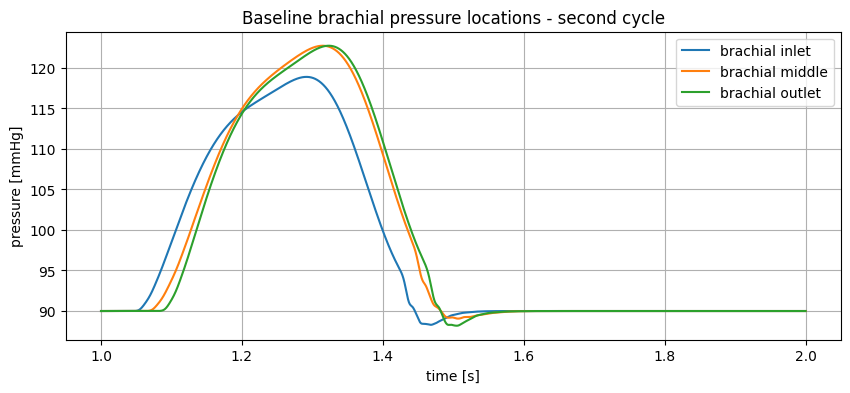

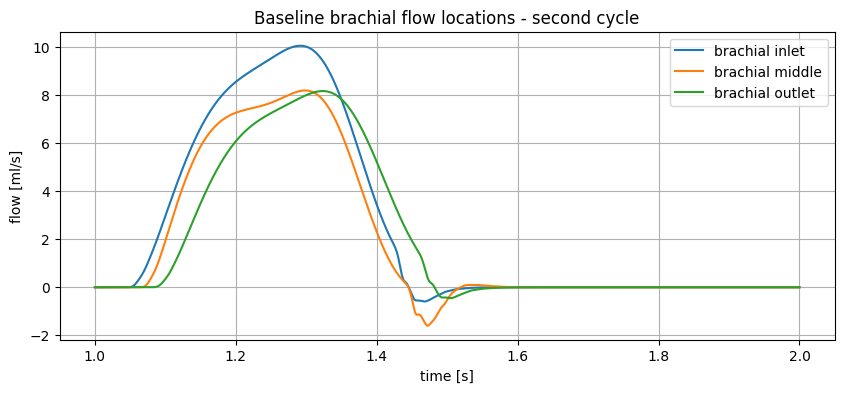

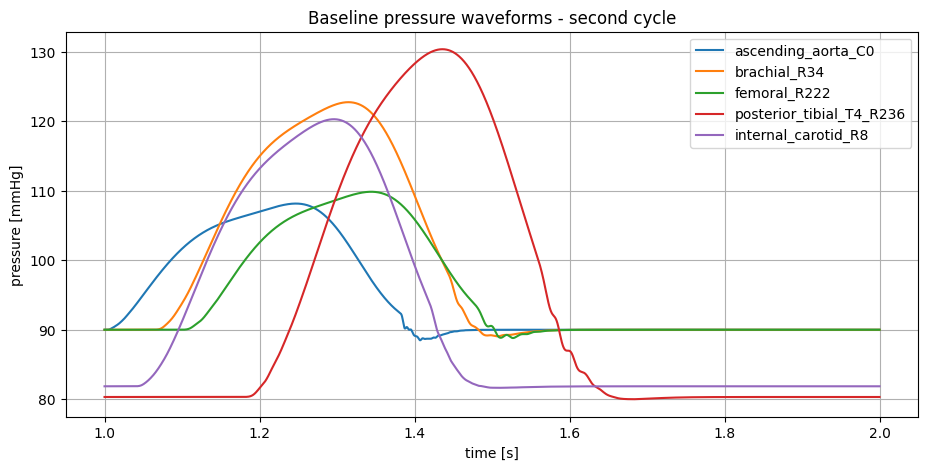

In [15]:
mask_cycle_2 = (t_arr >= 1.0) & (t_arr < 2.0)

plt.figure(figsize=(10, 4))
plt.plot(t_arr[mask_cycle_2], p_brachial_in_arr[mask_cycle_2], label="brachial inlet")
plt.plot(t_arr[mask_cycle_2], p_brachial_mid_arr[mask_cycle_2], label="brachial middle")
plt.plot(t_arr[mask_cycle_2], p_brachial_out_arr[mask_cycle_2], label="brachial outlet")
plt.xlabel("time [s]")
plt.ylabel("pressure [mmHg]")
plt.title("Baseline brachial pressure locations - second cycle")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_arr[mask_cycle_2], q_brachial_in_arr[mask_cycle_2], label="brachial inlet")
plt.plot(t_arr[mask_cycle_2], q_brachial_mid_arr[mask_cycle_2], label="brachial middle")
plt.plot(t_arr[mask_cycle_2], q_brachial_out_arr[mask_cycle_2], label="brachial outlet")
plt.xlabel("time [s]")
plt.ylabel("flow [ml/s]")
plt.title("Baseline brachial flow locations - second cycle")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(11, 5))
for name in watch_vessel_names:
    plt.plot(
        t_arr[mask_cycle_2],
        watch_pressure_arr[name][mask_cycle_2],
        label=name
    )

plt.xlabel("time [s]")
plt.ylabel("pressure [mmHg]")
plt.title("Baseline pressure waveforms - second cycle")
plt.legend()
plt.grid(True)
plt.show()